# **Proyek Cek-Gula**

dataset: [Dataset Gambar Jajan](https://drive.google.com/drive/folders/1MsjZWiTL2-V22t-O_Mv80VX7JrlNP18l?usp=sharing)

## **Main Quest:**

- Membangun model Deep Learning menggunakan TensorFlow Functional API atau Model Subclassing, yang disesuaikan dengan dataset dan permasalahan bisnis yang telah ditentukan oleh tim Data Science (jika ada).
- Mengimplementasikan setidaknya satu komponen kustom lanjutan dalam proses pengembangan model, seperti:
  - Custom Layer
  - Custom Loss Function
  - Custom Callback
- Menyimpan dan mengekspor model yang telah dilatih secara penuh dalam format TensorFlow siap produksi (.keras atau SavedModel).
- Membuat kode sederhana untuk proses inference model.

## **Tindakan yang Dilarang:**

- Menggunakan model yang sudah tersedia dari TensorFlow Hub atau sumber serupa.
- Menggunakan model langsung dari layanan API seperti ChatGPT API, Gemini API, dan sejenisnya.
- Menggunakan AutoML untuk membuat model Al diskriminatif (Vertex Al hanya diperbolehkan untuk use case Generative Al).

## **Side Quest:**

- Mengembangkan REST API mandiri menggunakan FastAPI atau Flask untuk melayani model machine learning.
- Mengimplementasikan training dan evaluation loop kustom secara penuh dari awal menggunakan tf.GradientTape.
- Menggunakan API Generative Al untuk fitur tambahan atau fitur sekunder pada aplikasi.
- Mengintegrasikan TensorBoard untuk memantau dan memvisualisasikan metrik pelatihan secara menyeluruh, serta menyertakan log yang dihasilkan dalam repository akhir.
- Memastikan model memiliki performa yang baik, dengan ketentuan minimum:
  - Akurasi minimal: 85%
  - MAE maksimal: 0,02


## **Import Library**


In [25]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import datetime, os
from tqdm.auto import tqdm

## **Load & Preprocessing Data**


In [2]:
DATASET_PATH = 'dataset_gambar'
BATCH_SIZE = 32
IMG_SIZE = (224, 224)
CORRUPTED = []
AUTOTUNE = tf.data.AUTOTUNE

In [3]:
all_files = []
for root, dirs, files in os.walk(DATASET_PATH):
	for fname in files:
		if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
			all_files.append(os.path.join(root, fname))

print(f"Total file: {len(all_files)}")

Total file: 8835


In [ ]:
for i, fpath in enumerate(all_files):
	try:
		raw = tf.io.read_file(fpath)
		tf.image.decode_image(raw, channels=3, expand_animations=False)
	except Exception as e:
		print(f"[KORUP] {fpath}\n		→ {e}")
		CORRUPTED.append(fpath)
	
	if (i+1) % 500 == 0:
		print(f"Progress: {i+1}/{len(all_files)}")

print(f"\nSelesai. Total bermasalah: {len(CORRUPTED)}")

Progress: 500/8835
Progress: 1000/8835
Progress: 1500/8835
Progress: 2000/8835
Progress: 2500/8835
Progress: 3000/8835
Progress: 3500/8835
Progress: 4000/8835
Progress: 4500/8835
Progress: 5000/8835
Progress: 5500/8835
Progress: 6000/8835
Progress: 6500/8835
Progress: 7000/8835
Progress: 7500/8835
Progress: 8000/8835
Progress: 8500/8835

Selesai. Total bermasalah: 0


In [ ]:
for fpath in CORRUPTED:
  os.remove(fpath)
  print(f"Dihapus: {fpath}")

In [4]:
class_names = sorted(os.listdir(DATASET_PATH))
num_classes = len(class_names)
class_to_idx = {name: i for i, name in enumerate(class_names)}

In [5]:
all_paths, all_labels = [], []
for class_name in class_names:
  class_dir = os.path.join(DATASET_PATH, class_name)
  if not os.path.isdir(class_dir):
    continue
  for fname in os.listdir(class_dir):
    if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
      all_paths.append(os.path.join(class_dir, fname))
      all_labels.append(class_to_idx[class_name])

In [6]:
def load_image(path, label):
  img = tf.io.read_file(path)
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img = tf.image.resize(img, IMG_SIZE)
  img = tf.cast(img, tf.float32)
  label = tf.one_hot(label, num_classes)
  return img, label

In [7]:
full_ds = tf.data.Dataset.from_tensor_slices((all_paths, all_labels))
full_ds = full_ds.shuffle(len(all_paths), seed=123)

total = len(all_paths)
train_size = int(total * 0.8)

In [8]:
train_dataset = (
  full_ds.take(train_size)
	.map(load_image,num_parallel_calls=AUTOTUNE)
	.batch(BATCH_SIZE)
	.prefetch(AUTOTUNE)
)

In [9]:
val_dataset = (
	full_ds.skip(train_size)
	.map(load_image, num_parallel_calls=AUTOTUNE)
	.batch(BATCH_SIZE)
	.prefetch(AUTOTUNE)
)

In [10]:
print(f"Train: {train_size} | Val: {total - train_size} | Kelas: {num_classes}")
print("\nClass names:", class_names)

Train: 7068 | Val: 1767 | Kelas: 100

Class names: ['ampyang', 'arem-arem', 'arum manis', 'bakpao', 'bakwan', 'biji salak', 'bika ambon', 'bolen', 'bolu gulung', 'bolu karamel', 'bolu kukus', 'brem', 'bubur mutiara', 'bubur sumsum', 'cenil', 'cilok', 'cimol', 'cireng', 'combro', 'dadar gulung', 'dodol', 'donat', 'gathot', 'geplak', 'getas', 'gethuk pisang', 'getuk goreng', 'getuk lindri', 'kembang goyang', 'keripik pisang', 'keripik singkong', 'keripik tempe', 'keukarah', 'klepon', 'kroket', 'kue akar kelapa', 'kue ape', 'kue apem', 'kue balok', 'kue bangkit', 'kue bawang', 'kue bingka', 'kue carabikang', 'kue cubit', 'kue cucur', 'kue gemblong', 'kue jipang', 'kue kacang', 'kue kamir', 'kue klemben', 'kue lekker', 'kue lidah kucing', 'kue lumpang', 'kue lumpur', 'kue lupis', 'kue manco', 'kue mendut', 'kue mochi', 'kue padamaran', 'kue pancong', 'kue pastel', 'kue pasung', 'kue perut ayam', 'kue pudak', 'kue pukis', 'kue putri mandi', 'kue putu', 'kue putu ayu', 'kue rangi', 'kue sago

## **Custom Callback**


In [11]:
class TargetAccuracyCallback(tf.keras.callbacks.Callback):
  def __init__(self, target_accuracy=0.95):
    super(TargetAccuracyCallback, self).__init__()
    self.target_accuracy = target_accuracy
    
  def on_epoch_end(self, epoch, logs=None):
    val_acc = logs.get('val_accuracy')
    if val_acc is not None and val_acc >= self.target_accuracy:
      print(f"\n[INFO] Akurasi validasi mencapai {val_acc*100:.2f}% (Target: {self.target_accuracy*100:.2f}%).")
      print("[INFO] Menghentikan proses training agar tidak overfitting!")
      self.model.stop_training = True

## **Custom Layer**


In [12]:
class NormalisasiGambar(tf.keras.layers.Layer):
  def __init__(self, **kwargs):
    super(NormalisasiGambar, self).__init__(**kwargs)
    
  def call(self, inputs):
    inputs = tf.cast(inputs, tf.float32)
    return (inputs / 127.5) - 1.0
  
  def get_config(self):
    config = super(NormalisasiGambar, self).get_config()
    return config

## **Membangun Model dengan Functional API**


In [13]:
def build_functional_model(num_classes):
  inputs = tf.keras.Input(shape=(224, 224, 3), name="input_gambar")
  
  # Augmentasi
  x = layers.RandomFlip("horizontal")(inputs)
  x = layers.RandomRotation(0.15)(x)
  x = layers.RandomZoom(0.15)(x)
  x = layers.RandomContrast(0.1)(x)
  
  # Custom Layer 
  x = NormalisasiGambar(name="normalisasi_gambar")(x)
  
  # Base model pretrained
  base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
	)
  base_model.trainable = False
  
  x = base_model(x, training=False)
  x = layers.GlobalAveragePooling2D()(x)
  x = layers.Dense(512, activation='relu')(x)
  x = layers.BatchNormalization()(x)
  x = layers.Dropout(0.5)(x)
  
  outputs = layers.Dense(num_classes, activation='softmax', name="prediksi_kelas")(x)
  model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Model_Cek_Gula")
  return model

In [15]:
model = build_functional_model(num_classes=num_classes)

for layer in model.layers:
  if 'normalisasi' in layer.name:
    print(f"Custom Layer: {layer.name} - {layer.__class__.__name__}")

model.summary()

Custom Layer: normalisasi_gambar - NormalisasiGambar


Model: "Model_Cek_Gula"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_gambar (InputLayer)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_1 (RandomFlip)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom_1 (RandomZoom)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_contrast_1               │ (None, 224, 224, 3)    │             0 │
│ (RandomContrast)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalisasi_gambar              │ (None, 224, 224, 3)    │             0 │
│ (NormalisasiGambar)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ prediksi_kelas (Dense)          │ (None, 100)            │        51,300 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,967,204 (11.32 MB)

 Trainable params: 708,196 (2.70 MB)

 Non-trainable params: 2,259,008 (8.62 MB)

# **Custom Training & Evaluation**


## **Optimizer, Loss, & Metrics**


In [54]:
EPOCHS = 50
LR = 0.0005
TARGET_ACC = 0.95
PATIENCE = 7
LR_FACTOR = 0.5
MIN_LR = 1e-6
LR_PAT = 3
CHECKPOINT = 'best_model.keras'
LOG_DIR = 'logs/fit/' + datetime.datetime.now().strftime('%Y%m%d-%H%M%S')

In [28]:
optimizer = tf.keras.optimizers.Adam(learning_rate=LR)
loss_fn = tf.keras.losses.CategoricalCrossentropy()

def make_metrics(prefix):
	return {
		'loss': tf.keras.metrics.Mean(name=f'{prefix}_loss'),
		'acc' : tf.keras.metrics.CategoricalAccuracy(name=f'{prefix}_accuracy'),
		'mae' : tf.keras.metrics.MeanAbsoluteError(name=f'{prefix}_mae'),
	}

train_m = make_metrics('train')
val_m = make_metrics('val')

## **TensorBoard Writers**


In [29]:
train_writer = tf.summary.create_file_writer(LOG_DIR + "/train")
val_writer = tf.summary.create_file_writer(LOG_DIR + "/val")

In [30]:
%load_ext tensorboard
%tensorboard --logdir logs/fit

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


ERROR: Failed to launch TensorBoard (exited with 1).
Contents of stderr:
Traceback (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "c:\Users\ASUS\AppData\Roaming\Python\Python312\Scripts\tensorboard.exe\__main__.py", line 2, in <module>
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\tensorboard\main.py", line 27, in <module>
    from tensorboard import default
  File "C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\tensorboard\default.py", line 30, in <module>
    import pkg_resources
ModuleNotFoundError: No module named 'pkg_resources'

## **train_step & val_step**


In [31]:
@tf.function
def train_step(images, labels):
  with tf.GradientTape() as tape:
    predictions = model(images, training=True)
    loss = loss_fn(labels, predictions)
    
  gradients = tape.gradient(loss, model.trainable_variables)
  optimizer.apply_gradients(zip(gradients, model.trainable_variables))
  
  train_m['loss'].update_state(loss)
  train_m['acc'].update_state(labels, predictions)
  train_m['mae'].update_state(labels, predictions)

In [32]:
@tf.function
def val_step(images, labels):
  predictions = model(images, training=False)
  loss = loss_fn(labels, predictions)
  
  val_m['loss'].update_state(loss)
  val_m['acc'].update_state(labels, predictions)
  val_m['mae'].update_state(labels, predictions)

## **Helper**


In [39]:
def reset_metrics():
  for m in [*train_m.values(), *val_m.values()]:
    m.reset_state()

In [34]:
def read_metrcis():
  return {
		'loss'    : float(train_m['loss'].result()),
		'accuracy': float(train_m['acc'].result()),
		'mae'     : float(train_m['mae'].result()),
		'val_loss'    : float(val_m['loss'].result()),
		'val_accuracy': float(val_m['acc'].result()),
		'val_mae'     : float(val_m['mae'].result()),
	}

In [35]:
def log_tensorboard(metrics, epoch):
  with train_writer.as_default():
    tf.summary.scalar('loss', metrics['loss'], step=epoch)
    tf.summary.scalar('accuracy', metrics['accuracy'], step=epoch)
    tf.summary.scalar('mae', metrics['mae'], step=epoch)
    tf.summary.scalar('learning_rate', float(optimizer.learning_rate), step=epoch)
  with val_writer.as_default():
    tf.summary.scalar('loss', metrics['val_loss'], step=epoch)
    tf.summary.scalar('accuracy', metrics['val_accuracy'], step=epoch)
    tf.summary.scalar('mae', metrics['val_mae'], step=epoch)

## **Training Loop**


In [ ]:
def training(model, train_dataset, val_dataset, epochs=EPOCHS, target_acc=TARGET_ACC, patience=PATIENCE, lr_patience=LR_PAT, checkpoint=CHECKPOINT):
  history = {k: [] for k in ['loss','accuracy','mae','val_loss','val_accuracy','val_mae']}
  best_val = 0.0
  pat_counter = 0
  no_improve = 0
  
  n_train = sum(1 for _ in train_dataset)
  n_val = sum(1 for _ in val_dataset)
  
  epoch_pbar = tqdm(range(1, epochs + 1), desc=f"[{model.name}]", unit='epoch')
  for epoch in epoch_pbar:
    reset_metrics()
    
    train_pbar = tqdm(train_dataset, leave=False, desc=f'  Epoch {epoch:3d} Train', unit='batch')
    for images, labels in train_pbar:
      train_step(images, labels)
      train_pbar.set_postfix(
				loss=f'{train_m["loss"].result():.5f}',
				acc =f'{train_m["acc"].result():.5f}',
			)
    
    val_pbar = tqdm(val_dataset, leave=False, desc=f'  Epoch {epoch:3d} Val  ', unit='batch')
    for images, labels in val_pbar:
      val_step(images, labels)
      val_pbar.set_postfix(
				val_loss=f'{val_m["loss"].result():.5f}',
				val_acc =f'{val_m["acc"].result():.5f}',
			)
      
    m = read_metrcis()
    for k, v, in m.items():
      history[k].append(v)
      
    epoch_pbar.set_postfix(
			loss = f'{m["loss"]:.5f}',
			acc = f'{m["accuracy"]:.5f}',
			val_loss = f'{m["val_loss"]:.5f}',
			val_acc = f'{m["val_accuracy"]:.5f}',
		)
    
    log_tensorboard(m, epoch)
    
    if m['val_accuracy'] > best_val:
      best_val = m['val_accuracy']
      best_loss = m['val_loss']
      pat_counter = 0
      no_improve = 0
      model.save(checkpoint)
      tqdm.write(f'Epoch {epoch} — model tersimpan (val_acc: {best_val:.5f}, val_loss: {best_loss:.5f})')
    else:
      pat_counter += 1
      no_improve += 1
    
    if m['val_accuracy'] >= target_acc:
      tqdm.write(f'\nTarget {target_acc*100:.0f}% tercapai di epoch {epoch}!')
      epoch_pbar.close()
      break
    
    if pat_counter >= patience:
      tqdm.write(f'\nEarlyStopping: {patience} epoch tanpa peningkatan.')
      epoch_pbar.close()
      break
    
    if no_improve > 0 and no_improve % lr_patience == 0:
      old_lr = float(optimizer.learning_rate)
      new_lr = max(old_lr * LR_FACTOR, MIN_LR)
      optimizer.learning_rate.assign(new_lr)
      tqdm.write(f'LR: {old_lr:.6f} → {new_lr:.6f}')
    
  tqdm.write(f'\nTraining selesai. Best val_acc: {best_val:.4f}')
  tqdm.write(f'TensorBoard: tensorboard --logdir {LOG_DIR}')
  return history

## **Training Model**


In [48]:
history = training(model=model, train_dataset=train_dataset, val_dataset=val_dataset)

[Model_Cek_Gula]:   0%|          | 0/50 [00:00<?, ?epoch/s]

  Epoch   1 Train:   0%|          | 0/221 [00:00<?, ?batch/s]

  Epoch   1 Val  :   0%|          | 0/56 [00:00<?, ?batch/s]

Epoch 1 — model tersimpan (val_acc: 0.90323, val_loss: 0.34439)


  Epoch   2 Train:   0%|          | 0/221 [00:00<?, ?batch/s]

...

  Epoch  22 Val  :   0%|          | 0/56 [00:00<?, ?batch/s]

LR: 0.000125 → 0.000063


  Epoch  23 Train:   0%|          | 0/221 [00:00<?, ?batch/s]

  Epoch  23 Val  :   0%|          | 0/56 [00:00<?, ?batch/s]


EarlyStopping: 7 epoch tanpa peningkatan.

Training selesai. Best val_acc: 0.9445
TensorBoard: tensorboard --logdir logs/fit/20260505-113523


## **Visualisasi Hasil Training**


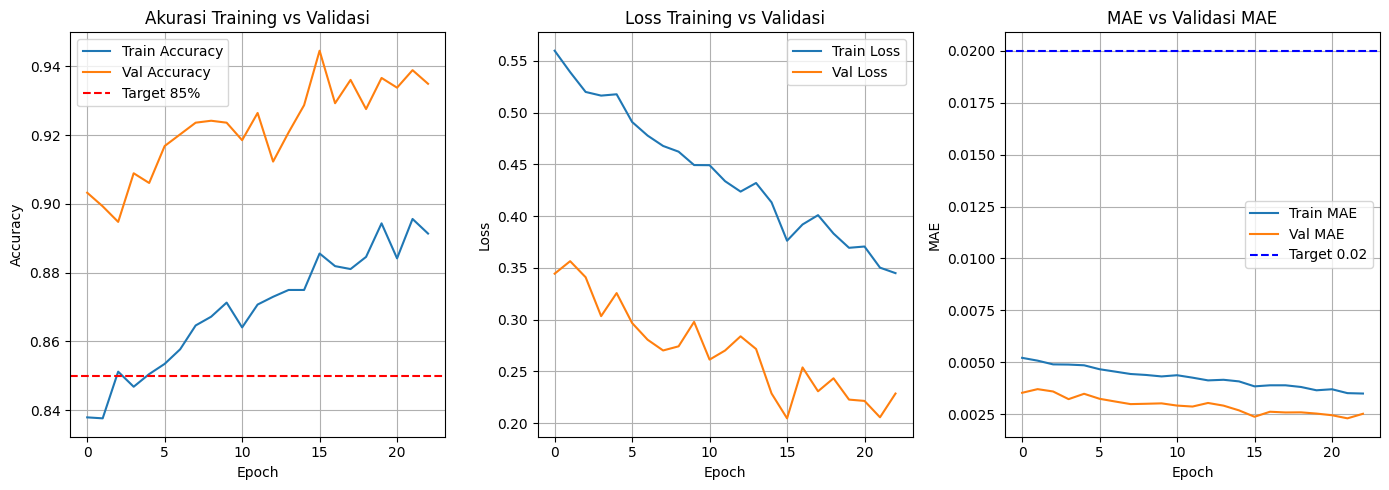

In [49]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(14, 5))

ax1.plot(history['accuracy'],     label="Train Accuracy")
ax1.plot(history['val_accuracy'], label="Val Accuracy")
ax1.axhline(y=0.85, color='r', linestyle='--', label='Target 85%')
ax1.set_title("Akurasi Training vs Validasi")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True)

ax2.plot(history['loss'],     label="Train Loss")
ax2.plot(history['val_loss'], label="Val Loss")
ax2.set_title("Loss Training vs Validasi")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True)

ax3.plot(history['mae'],     label="Train MAE")
ax3.plot(history['val_mae'], label="Val MAE")
ax3.axhline(y=0.02, color='b', linestyle='--', label='Target 0.02')
ax3.set_title("MAE vs Validasi MAE")
ax3.set_xlabel("Epoch"); ax3.set_ylabel("MAE")
ax3.legend(); ax3.grid(True)

plt.tight_layout()
plt.savefig('train_history.png', dpi=150)
plt.show()

In [51]:
best_val_acc = max(history['val_accuracy'])
print(f"\nPengecekkan Accuracy :")
print(f"Best Val Accuracy : {best_val_acc*100:.2f}%")
print(f"Target : 85.00%")
print(f"Status : {'✅ TERCAPAI' if best_val_acc >= 0.85 else '❌ Belum tercapai'}")


Pengecekkan Accuracy :
Best Val Accuracy : 94.45%
Target : 85.00%
Status : ✅ TERCAPAI


In [52]:
best_val_mae = min(history['val_mae'])
print(f"\nPengecekkan MAE :")
print(f"Best Val MAE : {best_val_mae:.4f}")
print(f"Target Maksimal : 0.02")
print(f"Status : {'✅ TERCAPAI' if best_val_mae <= 0.02 else '❌ Belum tercapai'}")


Pengecekkan MAE :
Best Val MAE : 0.0023
Target Maksimal : 0.02
Status : ✅ TERCAPAI


## **Save Model**


In [53]:
model.save('model_cek_gula.keras')

## **Dataset Nutrisi Jajan**


In [56]:
df_nutrisi = pd.read_csv('nutrisi_jajanan.csv', index_col='nama_jajanan')
NUTRISI = df_nutrisi.to_dict(orient='index')

print(f"Dataset nutrisi : {len(NUTRISI)} jenis jajanan")
df_nutrisi

Dataset nutrisi : 100 jenis jajanan


,kalori,karbohidrat,gula,protein,lemak,GI,GL
nama_jajanan,,,,,,,
ampyang,380,68.0,45.0,8.0,10.0,55,37.4
arem-arem,150,28.0,1.0,4.0,2.5,60,16.8
arum manis,390,75.0,60.0,2.0,8.0,70,52.5
bakpao,220,38.0,8.0,6.5,5.0,65,24.7
bakwan,175,20.0,1.5,5.0,8.0,55,11.0
...,...,...,...,...,...,...,...
tape ketan,165,38.0,20.0,2.0,0.5,65,24.7
tape singkong,145,34.0,18.0,1.5,0.5,60,20.4
tempe mendoan,200,16.0,1.0,12.0,10.0,45,7.2


## **Inference Model**


In [57]:
class NormalisasiGambar(tf.keras.layers.Layer):
	def __init__(self, **kwargs):
		super(NormalisasiGambar, self).__init__(**kwargs)

	def call(self, inputs):
		inputs = tf.cast(inputs, tf.float32)
		return (inputs / 127.5) - 1.0

	def get_config(self):
		config = super(NormalisasiGambar, self).get_config()
		return config

In [58]:
def kategori_resiko_gula(kadar_gula, gylcemic_load):
  if gylcemic_load < 10:
    return "🟢 RENDAH", "Aman dikonsumsi, risiko lonjakan gula minimal"
  elif gylcemic_load <20:
    return "🟡 SEDANG", "Konsumsi wajar, perhatikan porsi"
  else:
    return "🔴 TINGGI", "Batasi konsumsi, risiko sugar crash tinggi!"

In [61]:
def predict_gula(image_path, model, class_names, 
                 nutrisi_dict, porsi_gram=100):
  img = tf.io.read_file(image_path)
  img = tf.image.decode_image(img, channels=3, expand_animations=False)
  img = tf.image.resize(img, (224, 224))
  img_batch = tf.expand_dims(img, axis=0)
  
  predictions = model.predict(img_batch, verbose=0)
  predicted_idx = tf.argmax(predictions[0]).numpy()
  confidence = float(predictions[0][predicted_idx]) * 100
  
  top3_idx = tf.argsort(predictions[0], direction='DESCENDING')[:3]
  nama_jajanan = class_names[predicted_idx]
  
  print("=" * 50)
  print(f" 	HASIL ANALISIS CEK-GULA")
  print("=" * 50)
  print(f"  Jajanan    : {nama_jajanan.upper()}")
  print(f"  Keyakinan  : {confidence:.1f}%")
  print(f"  Porsi      : {porsi_gram}g")
  print("-" * 50)
  
  faktor_porsi = porsi_gram / 100.0
  if nama_jajanan in nutrisi_dict:
    n = nutrisi_dict[nama_jajanan]
    kalori    = n['kalori']    	 * faktor_porsi
    karbo     = n['karbohidrat'] * faktor_porsi
    gula      = n['gula']      	 * faktor_porsi
    protein   = n['protein']   	 * faktor_porsi
    lemak     = n['lemak']     	 * faktor_porsi
    gi        = n['GI']
    gl        = n['GL']        	 * faktor_porsi
    risiko, pesan = kategori_resiko_gula(gula, gl)
    
    print(f"	INFO NUTRISI (per {porsi_gram}g)")
    print(f"  Kalori     : {kalori:.0f} kkal")
    print(f"  Karbohidrat: {karbo:.1f} g")
    print(f"  Gula       : {gula:.1f} g kadar gula")
    print(f"  Protein    : {protein:.1f} g")
    print(f"  Lemak      : {lemak:.1f} g")
    print("-" * 50)
    print(f"  INDEKS GLIKEMIK (GI) : {gi}")
    print(f"  BEBAN GLIKEMIK  (GL) : {gl:.1f}")
    print(f"  Risiko     : {risiko}")
    print(f"  Info       : {pesan}")
    
  else:
    kalori = karbo = gula = protein = lemak = gi = gl = None
    risiko, pesan = "⚪ TIDAK DIKETAHUI", "Data nutrisi belum tersedia"

  print("-" * 50)
  print(f"  Top 3 Prediksi:")
  for i, idx in enumerate(top3_idx):
    print(f"     {i+1}. {class_names[idx]:<20} ({predictions[0][idx]*100:.1f}%)")
  print("=" * 50)
  
  return {
		'jajanan': nama_jajanan,
		'confidence': confidence,
		'gula_gram': gula,
		'kalori': kalori,
		'GI': gi,
		'GL': gl,
		'risiko': risiko
	}

In [63]:
model_path = 'best_model.keras'
model_gula = tf.keras.models.load_model(model_path, custom_objects={'NormalisasiGambar': NormalisasiGambar})

hasil = predict_gula(
	image_path='images.jpg',
	model=model_gula,
	class_names=class_names,
	nutrisi_dict=NUTRISI,
	porsi_gram=100
)

 	HASIL ANALISIS CEK-GULA
  Jajanan    : RISOL
  Keyakinan  : 98.7%
  Porsi      : 100g
--------------------------------------------------
	INFO NUTRISI (per 100g)
  Kalori     : 190 kkal
  Karbohidrat: 22.0 g
  Gula       : 2.0 g kadar gula
  Protein    : 6.0 g
  Lemak      : 8.5 g
--------------------------------------------------
  INDEKS GLIKEMIK (GI) : 52
  BEBAN GLIKEMIK  (GL) : 11.4
  Risiko     : 🟡 SEDANG
  Info       : Konsumsi wajar, perhatikan porsi
--------------------------------------------------
  Top 3 Prediksi:
     1. risol                (98.7%)
     2. tahu isi             (1.2%)
     3. keripik singkong     (0.0%)
